In [46]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import read_csv

In [47]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [48]:
df = read_csv("/Users/filippopalandri/Desktop/UNI/DataScience_material/Fraud_detection/AIML Dataset.csv")

In [49]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [50]:
print(df["amount"].isnull())

0          False
1          False
2          False
3          False
4          False
           ...  
6362615    False
6362616    False
6362617    False
6362618    False
6362619    False
Name: amount, Length: 6362620, dtype: bool


In [51]:
#returns columns and rows of the dataframe
df.shape

(6362620, 11)

Text(0.5, 0, 'Counts')

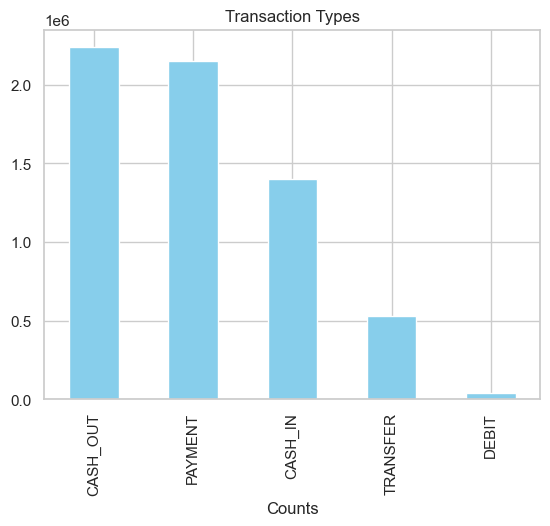

In [52]:
df["type"].value_counts().plot(kind="bar", title = "Transaction Types", color = "skyblue")
plt.xlabel("Transaction Types")
plt.xlabel("Counts")

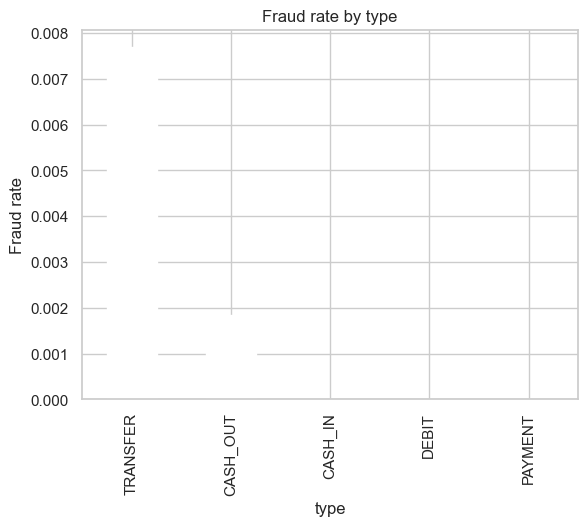

In [53]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False) #group by type and then ratain only the isFraud columm
fraud_by_type.plot(kind = "bar", title = "Fraud rate by type", color = "white") #plot the fraud rates by type
plt.ylabel("Fraud rate")
plt.show()

In [54]:
df["amount"].describe().astype(int) #statistics for the amount variable


count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

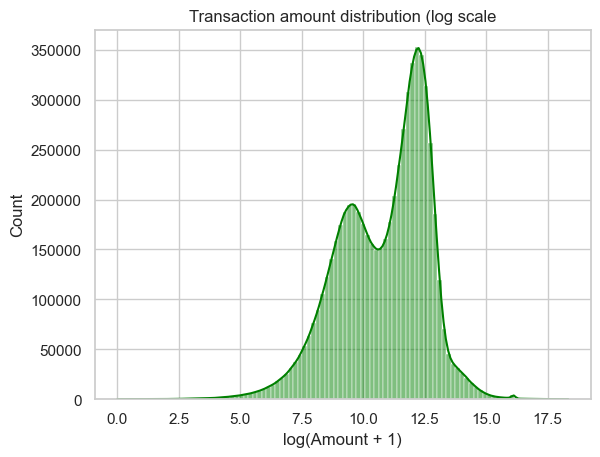

In [55]:
sns.histplot(np.log1p(df["amount"]),bins = 100, kde = True, color = "green" )
plt.title("Transaction amount distribution (log scale")
plt.xlabel("log(Amount + 1)")
plt.show()

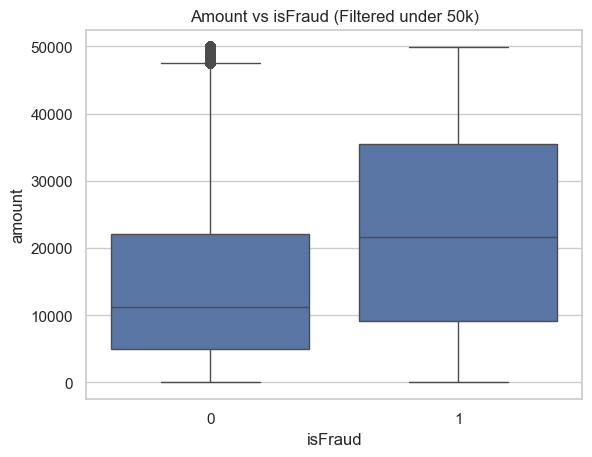

In [56]:
sns.boxplot(data = df[df["amount"] < 50000], x ="isFraud", y = "amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [57]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [58]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"] #change in the balance
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [59]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

In [60]:
(df["balanceDiffDest"] < 0).sum()

np.int64(1238864)

Text(0, 0.5, 'Number of Frauds')

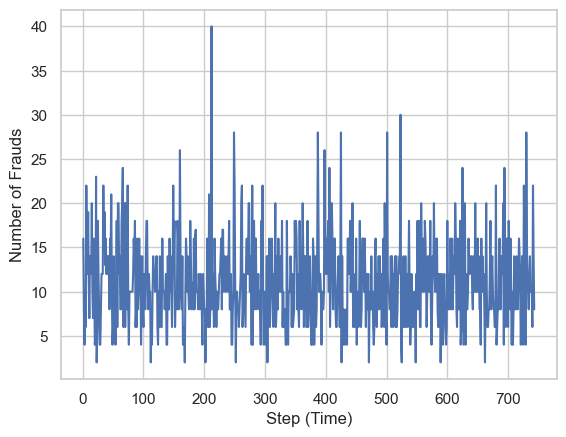

In [61]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index() #check time dependency in the distribution of frauds
plt.plot(frauds_per_step.index, frauds_per_step.values, label = "Frauds per Step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")

In [62]:
df.drop(columns = "step", inplace = True)

In [63]:
top_senders = df["nameOrig"].value_counts().head(10) #print top senders

In [64]:
top_senders

nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

In [65]:
top_receivers = df["nameDest"].value_counts().head(10)

In [66]:
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [67]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])] #takes only the rows that have as type "PAYMENT" or "CASH_OUT"

In [68]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

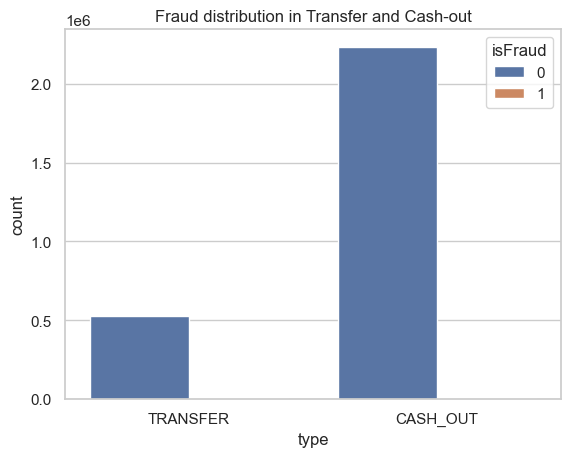

In [69]:
sns.countplot(data = fraud_types, x="type", hue = "isFraud")
plt.title("Fraud distribution in Transfer and Cash-out")
plt.show()

In [70]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [71]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [72]:
corr


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


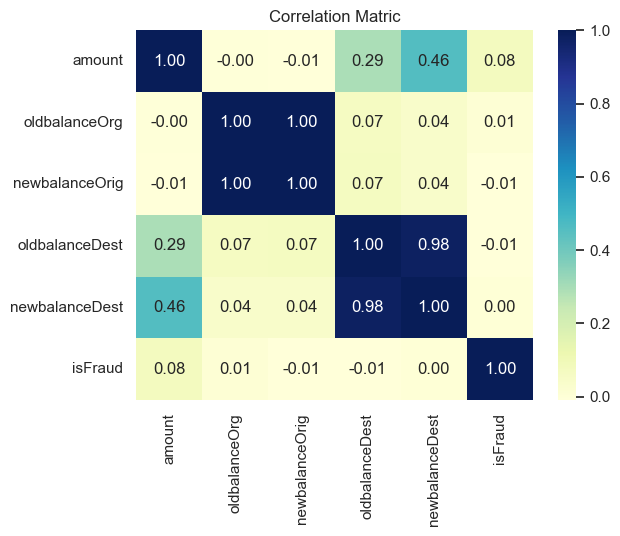

In [73]:
sns.heatmap(corr, annot = True, cmap = "YlGnBu", fmt=".2f")
plt.title("Correlation Matric")
plt.show()

In [74]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [75]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import  Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [77]:
df_model = df.drop(["nameOrig", "isFlaggedFraud"], axis = 1)
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,M1979787155,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,M2044282225,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,C553264065,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,C38997010,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,M1230701703,0.0,0.0,0,11668.14,0.0


In [78]:
df_model = df_model.drop("nameDest", axis = 1)
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [79]:
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

In [80]:
y = df_model["isFraud"]
x = df_model.drop("isFraud", axis = 1)


In [81]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, stratify = y)

In [82]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric), #scales the numerical variables
        ("cat", OneHotEncoder(drop = "first"), categorical) #convert categories into binary columns
    ],
    remainder= "drop"
)

In [83]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight = "balanced", max_iter = 1000))
])

In [84]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [85]:
y_pred = pipeline.predict(X_test)

In [86]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [87]:
confusion_matrix(y_test, y_pred)

array([[1803853,  102469],
       [    148,    2316]])

In [90]:
pipeline.score(X_test, y_test) *100

94.62396517996255

In [106]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [91]:
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(x, y, test_size = 0.3, stratify = y) #split the dataset

In [96]:
preprocessor_tree = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric), #scales the numerical variables
        ("cat", OneHotEncoder(drop = "first"), categorical) #convert categories into binary columns
    ],
    remainder= "drop"
)

In [97]:
pipeline_tree = Pipeline([
    ("prep", preprocessor_tree),
    ("clf", DecisionTreeClassifier(random_state=42))
])

In [98]:
pipeline_tree.fit(X_train_tree, y_train_tree)
y_pred_tree = pipeline_tree.predict(X_test_tree)

In [99]:
print(classification_report(y_test_tree, y_pred_tree)) #note that the decision tree do much better in precision and in accuracy, the F1 is excellent compared to the previuos model


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.91      0.90      0.90      2464

    accuracy                           1.00   1908786
   macro avg       0.95      0.95      0.95   1908786
weighted avg       1.00      1.00      1.00   1908786



In [101]:
pipeline_tree.score(X_test_tree, y_test_tree)*100

99.97448640130429

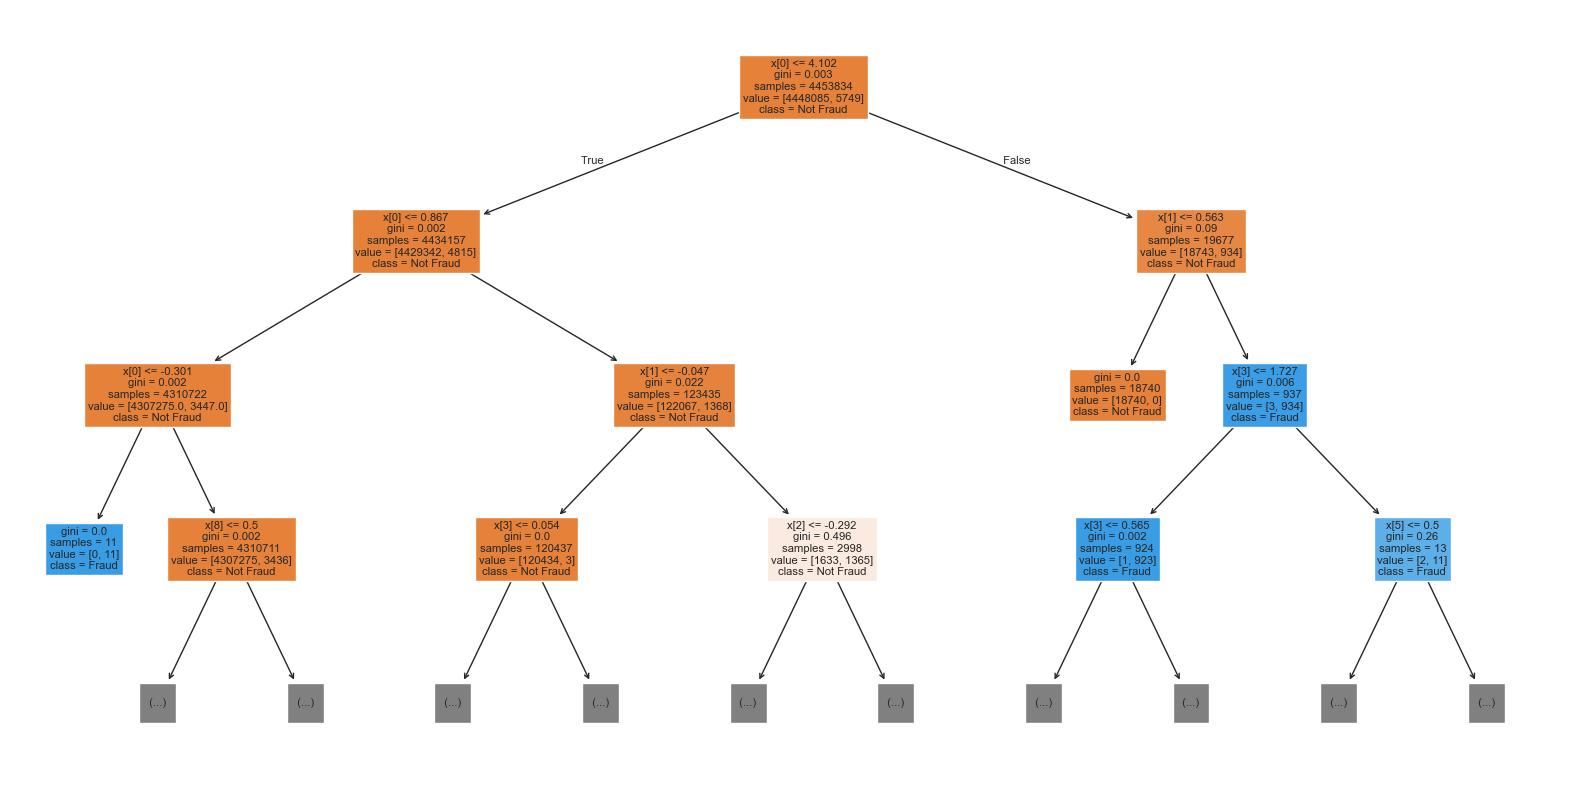

In [107]:
tree_model = pipeline_tree.named_steps["clf"]

plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    filled=True,
    class_names=["Not Fraud", "Fraud"],
    max_depth=3
)

plt.show()  #cannot see the variable names

In [89]:
import joblib
joblib.dump(pipeline, "fruad_detection_pipeline.pkl")

['fruad_detection_pipeline.pkl']